# Risk Parity and Common Performance Evaluation

Builds the **risk parity** (equal risk contribution) portfolio on the same CRSP universe and
single-factor covariance used for minimum risk, and provides the **common evaluation
layer** every strategy in the comparison goes through.

| Section | Content |
|---|---|
| §2 | Risk decomposition and what risk parity asks for |
| §3 | One rebalance: three solvers agree, risk contributions are equal |
| §4 | Full backtest through `backtest.rolling_backtest`, alignment checks |
| §5 | Performance table, cross-checked against `backtest.summarize` |
| §6 | Cumulative returns, drawdowns, subperiods |
| §7 | Risk-contribution concentration across portfolios |

Code lives in `risk_parity.py` (solvers, risk contributions) and `performance.py`
(metrics, turnover, concentration diagnostics, alignment checks).

## 1. Setup and data

In [1]:
import os, sys, time, warnings
# Run from the project root whether the kernel starts there or in analysis/.
if not os.path.exists("data") and os.path.exists(os.path.join("..", "data")):
    os.chdir("..")
sys.path.insert(0, os.getcwd())
# numpy on macOS Accelerate emits spurious matmul RuntimeWarnings; results are unaffected.
warnings.filterwarnings("ignore", category=RuntimeWarning, message=".*encountered in matmul")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from estimation import estimate_single_factor
from portfolios import min_risk_closed_form
from backtest import select_universe, rolling_backtest, summarize
from risk_parity import (risk_parity, risk_parity_closed_form, risk_parity_weights,
                         risk_parity_cvxpy, risk_contributions, rc_dispersion)
from performance import (returns_from_panel, performance_table, subperiod_table,
                         cumulative_returns, drawdowns, estimate_covs,
                         risk_concentration, check_alignment)

pd.set_option("display.width", 140)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
plt.rcParams.update({
    "figure.figsize": (11, 4.5), "axes.grid": True, "grid.alpha": 0.25,
    "axes.spines.top": False, "axes.spines.right": False, "lines.linewidth": 1.5,
})

# One fixed colour per strategy, so a strategy keeps its colour in every chart
# no matter which others are plotted alongside it.
COLORS = {"min_risk": "#2a78d6", "max_div": "#eb6834", "risk_parity": "#1baf7a",
          "ew": "#eda100", "vw": "#e87ba4"}
LABELS = {"min_risk": "Minimum risk", "max_div": "Maximum diversification",
          "risk_parity": "Risk parity", "ew": "Equally weighted", "vw": "Value weighted"}

Same data preparation as `min_risk_port.ipynb`, so the universe is identical: NYSE /
NYSE American / Nasdaq only, French's data divided by 100, everything keyed on `yyyymm`.

In [2]:
crsp = pd.read_parquet("data/crsp_msf_v2.parquet",
                       columns=["permno", "yyyymm", "mthret", "mthcap", "primaryexch"])
crsp = crsp[crsp.primaryexch.isin(["N", "A", "Q"])]
ff = pd.read_csv("data/MktRf.csv", index_col=0)

rets = crsp.pivot_table(index="yyyymm", columns="permno", values="mthret")
caps = crsp.pivot_table(index="yyyymm", columns="permno", values="mthcap")
mkt = (ff["Mkt-RF"] / 100.0).reindex(rets.index)
rf = (ff["RF"] / 100.0).reindex(rets.index)
assert not mkt.isna().any() and not rf.isna().any()
assert 0.03 < mkt.std() < 0.07, "Mkt-RF units look wrong -- did you divide by 100?"

START_YEAR, END_YEAR, T, N = 1995, 2025, 60, 500
idx = rets.index
i_first = idx.get_loc(START_YEAR * 100 + 1) - 1
i_last = idx.get_loc(END_YEAR * 100 + 12) - 1
print(f"panel {rets.shape[0]} months x {rets.shape[1]:,} stocks; "
      f"rebalances {idx[i_first]}..{idx[i_last]}, {i_last - i_first + 1} out-of-sample months")

panel 432 months x 18,898 stocks; rebalances 199412..202511, 372 out-of-sample months


## 2. Risk contributions and risk parity

Portfolio volatility $\sigma_p = \sqrt{x^\top V x}$ is homogeneous of degree one in $x$, so
Euler's theorem splits it exactly across holdings:

$$
\text{MRC}_i = \frac{\partial \sigma_p}{\partial x_i} = \frac{(Vx)_i}{\sigma_p},
\qquad
\text{RC}_i = x_i\,\text{MRC}_i,
\qquad
\sum_i \text{RC}_i = \sigma_p .
$$

**Risk parity** requires $\text{RC}_i = \sigma_p / n$ for every name. The long-only solution
is the rescaled minimiser of the strictly convex problem

$$\min_{y>0}\ \tfrac12\, y^\top V y - \sum_i \log y_i ,$$

whose first-order condition $y_i (Vy)_i = 1$ is exactly equal variance contributions.

**Single-factor shortcut.** With $V = \sigma_M^2 \beta\beta^\top + \mathrm{Diag}(\omega^2)$ and
$b = \beta^\top y$, each condition becomes a scalar quadratic
$\omega_i^2 y_i^2 + \sigma_M^2 \beta_i b\, y_i - 1 = 0$ with one positive root. The whole
solution is pinned down by the scalar $b$, found by bisection on $b = \beta^\top y(b)$ —
the same structure as the $\beta_{LO}$ threshold of the minimum-risk closed form.

Compare the three portfolios' structure under this model:

* **Minimum risk** holds only $\beta_i < \beta_{LO}$. KKT forces equal *marginal* risk on the
  held names, so each name's risk share equals its weight.
* **Risk parity** holds every name, with equal *total* risk contributions.
* **Equal weight** has equal weights, so high-beta, high-volatility names carry more risk.

## 3. One rebalance, step by step

In [3]:
t = idx[i_first]
window = idx[i_first - T + 1 : i_first + 1]
universe = select_universe(rets, caps, window, t, N)
R = rets.loc[window, universe].values - rf.loc[window].values[:, None]
cov = estimate_single_factor(R, mkt.loc[window].values, permno=universe.values)
print(f"rebalance {t}: {cov.n} stocks, window {window[0]}..{window[-1]}")

timings, solutions = {}, {}
for name, solve in [("closed form (factor)", lambda: risk_parity_closed_form(cov)),
                    ("Newton (dense V)", lambda: risk_parity_weights(cov.to_dense())),
                    ("cvxpy (factor)", lambda: risk_parity_cvxpy(cov))]:
    t0 = time.perf_counter(); solutions[name] = solve(); timings[name] = time.perf_counter() - t0

x_rp = solutions["closed form (factor)"]
for name, x in solutions.items():
    print(f"{name:22s} {timings[name]*1000:9.2f} ms   max |x - closed form| = "
          f"{np.abs(x - x_rp).max():.1e}   RC dispersion = {rc_dispersion(x, cov):.1e}")

assert np.abs(solutions["Newton (dense V)"] - x_rp).max() < 1e-10
assert np.abs(solutions["cvxpy (factor)"] - x_rp).max() < 1e-5

rebalance 199412: 500 stocks, window 199001..199412


closed form (factor)        0.63 ms   max |x - closed form| = 0.0e+00   RC dispersion = 1.6e-15
Newton (dense V)           21.26 ms   max |x - closed form| = 4.3e-18   RC dispersion = 1.1e-15
cvxpy (factor)           1273.71 ms   max |x - closed form| = 1.2e-07   RC dispersion = 5.0e-05


### Verify the equalisation

`rc_dispersion` is $\max_i |n\,p_i - 1|$ with $p_i = \text{RC}_i/\sigma_p$, zero for exact risk
parity. The Euler identity $\sum_i \text{RC}_i = \sigma_p$ is checked too, as is the minimum-risk
KKT property (risk share equals weight).

In [4]:
x_mr = min_risk_closed_form(cov)["x"]
x_ew = np.full(cov.n, 1.0 / cov.n)

rc = {k: risk_contributions(x, cov) for k, x in
      [("min_risk", x_mr), ("risk_parity", x_rp), ("ew", x_ew)]}
for k, d in rc.items():
    print(f"{LABELS[k]:18s} sigma_p {d['sigma_p']*np.sqrt(12):.4f} ann.   "
          f"Euler gap {d['euler_gap']:.1e}   largest risk share {d['share'].max():.2%}")

assert rc_dispersion(x_rp, cov) < 1e-8, "risk contributions are not equal"
assert all(d["euler_gap"] < 1e-12 for d in rc.values())
held = x_mr > 0
assert np.allclose(rc["min_risk"]["share"][held], x_mr[held], atol=1e-10), "min risk KKT violated"
assert np.allclose(rc["min_risk"]["mrc"][held], rc["min_risk"]["sigma_p"]), "min risk MRCs not equal"
print("\nrisk parity: equal RC; minimum risk: equal MRC on held names, risk share = weight")

Minimum risk       sigma_p 0.0747 ann.   Euler gap 3.2e-16   largest risk share 8.45%
Risk parity        sigma_p 0.1273 ann.   Euler gap 9.4e-16   largest risk share 0.20%
Equally weighted   sigma_p 0.1404 ann.   Euler gap 0.0e+00   largest risk share 0.42%

risk parity: equal RC; minimum risk: equal MRC on held names, risk share = weight


The chart sorts names by risk share and accumulates. A portfolio whose risk is spread
evenly follows the diagonal; the further the curve bows up, the fewer names carry the risk.

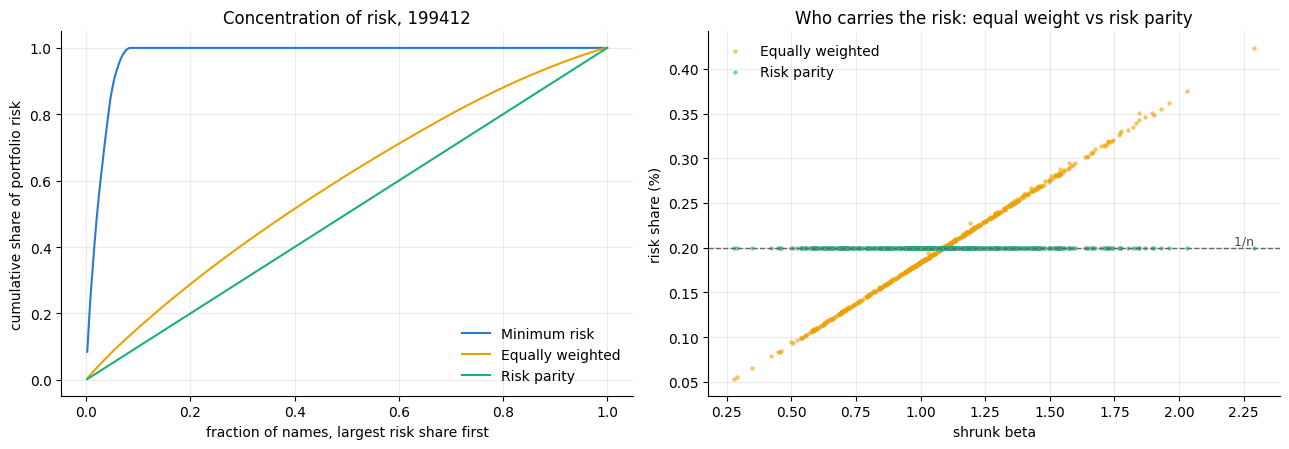

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.6))
grid = np.arange(1, cov.n + 1) / cov.n
for k in ["min_risk", "ew", "risk_parity"]:
    s = np.sort(rc[k]["share"])[::-1]
    ax[0].plot(grid, np.cumsum(s), color=COLORS[k], label=LABELS[k])
ax[0].set_xlabel("fraction of names, largest risk share first")
ax[0].set_ylabel("cumulative share of portfolio risk")
ax[0].set_title(f"Concentration of risk, {t}")
ax[0].legend(frameon=False, loc="lower right")

# Risk share against beta: the mechanism behind each shape.
for k, marker in [("ew", "o"), ("risk_parity", "o")]:
    ax[1].scatter(cov.beta, rc[k]["share"] * 100, s=10, alpha=0.6, color=COLORS[k],
                  label=LABELS[k], marker=marker, linewidths=0)
ax[1].axhline(100 / cov.n, color="0.4", lw=1, ls="--")
ax[1].text(cov.beta.max(), 100 / cov.n, " 1/n", va="bottom", ha="right", color="0.3", fontsize=9)
ax[1].set_xlabel("shrunk beta"); ax[1].set_ylabel("risk share (%)")
ax[1].set_title("Who carries the risk: equal weight vs risk parity")
ax[1].legend(frameon=False)
plt.tight_layout(); plt.show()

## 4. Full rolling backtest

Risk parity plugs into the shared `rolling_backtest` through its `constructors` argument,
so it uses exactly the same universe selection, covariance estimate, delisting and turnover
conventions as minimum risk. Teammates' constructors (maximum diversification, EW, VW) go into
the same dictionary.

In [6]:
CONSTRUCTORS = {
    "min_risk": min_risk_closed_form,
    "risk_parity": risk_parity,
    # "max_div": ...,   # added when the teammates' constructors are merged
    # "ew": ...,
    # "vw": ...,
}

t0 = time.perf_counter()
panel, weights = rolling_backtest(rets, caps, mkt, rf, T=T, n=N,
                                  start=idx[i_first], end=idx[i_last],
                                  constructors=CONSTRUCTORS)
print(f"backtest finished in {time.perf_counter() - t0:.1f}s")
returns = returns_from_panel(panel)
print(f"{len(returns)} months x {returns.shape[1]} strategies")

backtest finished in 4.8s
372 months x 2 strategies


### Same months, same universe

`check_alignment` raises if any strategy is missing a month, rebalances on different dates,
draws from a different universe on any date, is not fully invested and long only, or earns
returns in months that do not follow its rebalance dates. Run it again on the final
five-strategy set before building the comparison table.

In [7]:
check_alignment(returns, weights, asset_returns=rets)
assert len(returns) == 372
print("alignment checks passed: identical months, rebalance dates and universes; "
      "weights fully invested and long only")

alignment checks passed: identical months, rebalance dates and universes; weights fully invested and long only


## 5. Performance table

Conventions (module docstring of `performance.py`): geometric annualised return; volatility
and Sharpe on **excess** returns; drawdown on the compounded path; one-way turnover against
**drifted** weights. `performance_table` recomputes turnover independently from the weights
and the return panel, so matching `backtest.summarize` checks both pieces of code.

In [8]:
table = performance_table(returns, weights, rf=rf, asset_returns=rets, mkt=mkt)

ref = summarize(panel)
for col in ["ann_return", "ann_vol", "sharpe", "max_drawdown", "ann_turnover"]:
    gap = np.abs(table[col] - ref.loc[table.index, col]).max()
    assert gap < 1e-12, f"{col} disagrees with backtest.summarize by {gap:.1e}"
print("every metric matches backtest.summarize to 1e-12\n")

display_table = table.rename(index=LABELS)
display_table

every metric matches backtest.summarize to 1e-12



,months,ann_return,ann_vol,sharpe,max_drawdown,cum_return,ann_turnover,beta
Minimum risk,372.0000,0.0820,0.1272,0.4992,-0.3755,10.5178,1.1662,0.3395
Risk parity,372.0000,0.1162,0.1404,0.6890,-0.4890,29.2089,0.6241,0.8457


## 6. Cumulative returns, drawdowns, subperiods

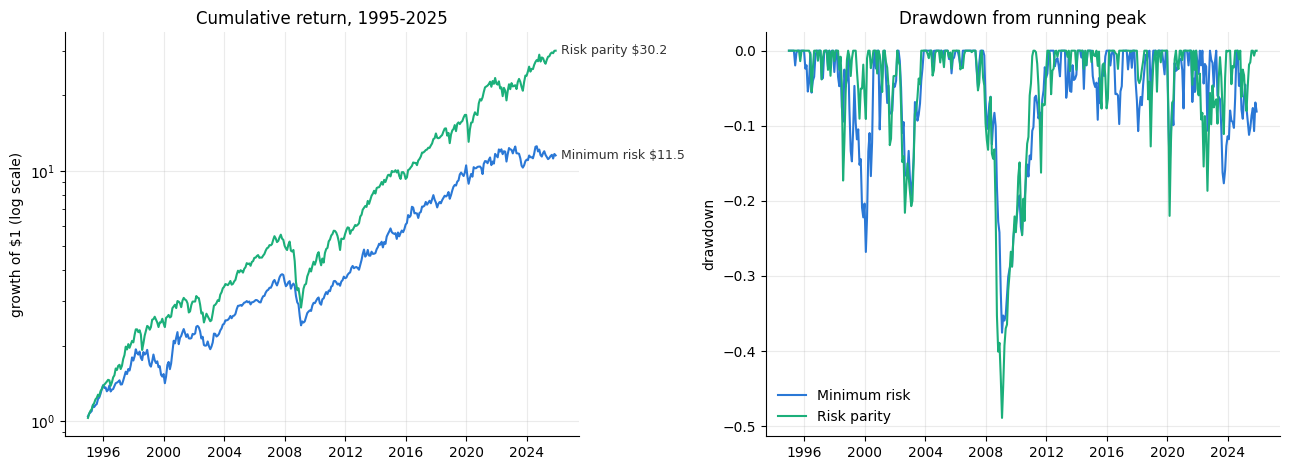

In [9]:
when = pd.PeriodIndex([str(d) for d in returns.index], freq="M").to_timestamp()
wealth = 1.0 + cumulative_returns(returns)
dd = drawdowns(returns)

fig, ax = plt.subplots(1, 2, figsize=(13, 4.8))
for k in returns.columns:
    ax[0].plot(when, wealth[k], color=COLORS[k], label=LABELS[k])
    ax[0].annotate(f"{LABELS[k]} ${wealth[k].iloc[-1]:.1f}", (when[-1], wealth[k].iloc[-1]),
                   xytext=(4, 0), textcoords="offset points", va="center", fontsize=9, color="0.2")
    ax[1].plot(when, dd[k], color=COLORS[k], label=LABELS[k])
ax[0].set_yscale("log"); ax[0].set_ylabel("growth of $1 (log scale)")
ax[0].set_title("Cumulative return, 1995-2025")
ax[1].set_ylabel("drawdown"); ax[1].set_title("Drawdown from running peak")
ax[1].legend(frameon=False, loc="lower left")
plt.tight_layout(); plt.show()

In [10]:
PERIODS = [(199501, 199912, "1995-1999"), (200001, 200912, "2000-2009"),
           (201001, 201912, "2010-2019"), (202001, 202512, "2020-2025")]
sub = subperiod_table(returns, weights, periods=PERIODS, rf=rf, asset_returns=rets, mkt=mkt)
sub[["ann_return", "ann_vol", "sharpe", "max_drawdown", "beta"]].rename(index=LABELS, level="strategy")

ann_return  ann_vol  sharpe  max_drawdown   beta
period    strategy                                                      
1995-1999 Minimum risk      0.0848   0.1308  0.3070       -0.2219 0.3382
          Risk parity       0.2067   0.1302  1.1347       -0.1729 0.8481
2000-2009 Minimum risk      0.0702   0.1340  0.3726       -0.3755 0.3184
          Risk parity       0.0539   0.1459  0.2484       -0.4890 0.7905
2010-2019 Minimum risk      0.1275   0.1052  1.1493       -0.1071 0.2977
          Risk parity       0.1448   0.1194  1.1545       -0.1624 0.9097
2020-2025 Minimum risk      0.0267   0.1448  0.0688       -0.1766 0.4341
          Risk parity       0.1036   0.1684  0.5131       -0.2200 0.8982

## 7. Risk-contribution concentration

`rolling_backtest` does not keep its covariance estimates, so `estimate_covs` rebuilds them
from the same window and universe at each rebalance. Every portfolio is then evaluated against
the same $V_t$. Equal weight over the same universe is included as a reference point; it is a
diagnostic here, not a strategy.

* `eff_n_risk` $= 1/\sum_i p_i^2$ is the effective number of independent risk bets
  (500 means perfectly even, 1 means one name carries everything).
* `systematic_share` $= \sigma_M^2(\beta^\top x)^2 / x^\top V x$ is the part of ex-ante variance
  coming from the market factor.

In [11]:
covs = estimate_covs(weights["risk_parity"], rets, mkt, rf, T=T)
w_ew = weights["risk_parity"].notna().astype(float)
w_ew = w_ew.div(w_ew.sum(axis=1), axis=0).where(weights["risk_parity"].notna())

diag_w = {**weights, "ew": w_ew}
conc = {k: risk_concentration(w, covs) for k, w in diag_w.items()}

assert conc["risk_parity"].rc_dispersion.max() < 1e-8, "risk parity failed to equalise in some month"
print(f"risk parity: max RC dispersion over all {len(covs)} months = "
      f"{conc['risk_parity'].rc_dispersion.max():.1e}\n")

cols = ["n_held", "eff_n_weight", "eff_n_risk", "max_rc_share", "top10_rc_share", "systematic_share"]
pd.DataFrame({LABELS[k]: c[cols].mean() for k, c in conc.items()}).T

risk parity: max RC dispersion over all 372 months = 2.9e-14



,n_held,eff_n_weight,eff_n_risk,max_rc_share,top10_rc_share,systematic_share
Minimum risk,45.1156,25.3440,25.3440,0.0876,0.5398,0.7316
Risk parity,500.0000,423.6350,500.0000,0.0020,0.0200,0.9893
Equally weighted,500.0000,500.0000,437.0646,0.0058,0.0453,0.9912


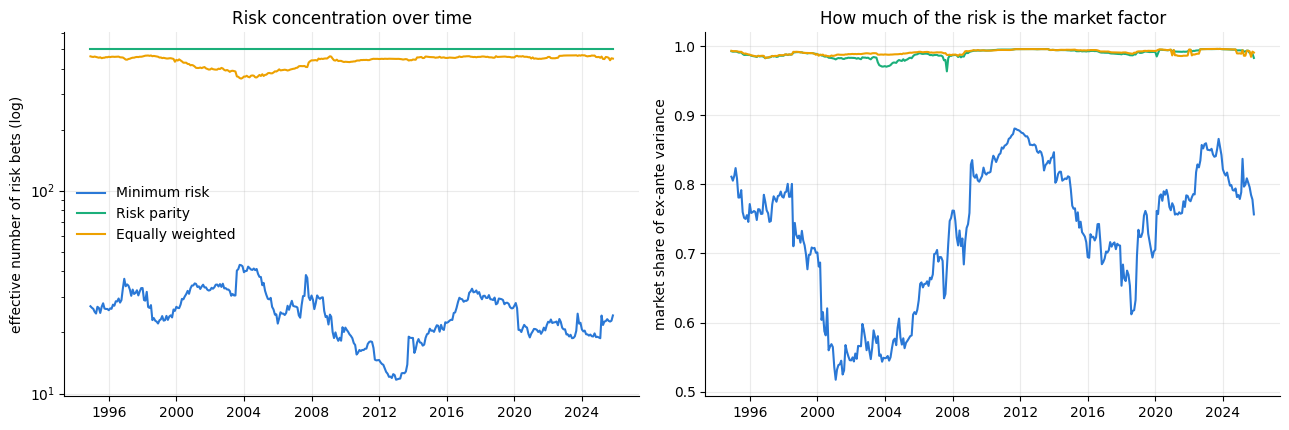

In [12]:
reb = pd.PeriodIndex([str(d) for d in covs], freq="M").to_timestamp()
fig, ax = plt.subplots(1, 2, figsize=(13, 4.4))
for k, c in conc.items():
    ax[0].plot(reb, c.eff_n_risk, color=COLORS[k], label=LABELS[k])
    ax[1].plot(reb, c.systematic_share, color=COLORS[k], label=LABELS[k])
ax[0].set_yscale("log"); ax[0].set_ylabel("effective number of risk bets (log)")
ax[0].set_title("Risk concentration over time")
ax[1].set_ylabel("market share of ex-ante variance")
ax[1].set_title("How much of the risk is the market factor")
ax[0].legend(frameon=False, loc="center left")
plt.tight_layout(); plt.show()

## Summary

* **Risk parity is solved exactly and fast.** Under the single-factor covariance it reduces
  to a one-dimensional root search. The closed form, Newton's method on the dense matrix,
  and cvxpy all agree, and risk contributions are equal to machine precision in every one of
  the 372 rebalances.
* **The shared evaluation layer reproduces `backtest.summarize` exactly**, including turnover
  recomputed independently from stored weights, so all five strategies can go through it.
* **Risk concentration separates the approaches cleanly.** Minimum risk spreads its risk over
  about 25 effective bets. Risk parity spreads it over all 500 by construction, and equal
  weight lands close behind.
* **"Equal risk across stocks" is not "diversified across sources of risk".** Under a
  single-factor model nearly all of risk parity's ex-ante variance is the market factor.
  Minimum risk is the only one of the three that materially reduces market exposure, which is
  where its lower volatility comes from.

### To do when teammates' series are in

1. Add `max_div`, `ew`, `vw` constructors to `CONSTRUCTORS` in §4 and re-run.
2. `check_alignment` must pass on all five.
3. The tables and charts in §5-§7 pick up every strategy automatically.